### Получаем данные

In [3]:
from src.mlcore.dataloader import get_processed_data

raw = get_processed_data(source='local', symbol='BTCUSDC')
raw

,exchange_ts,open,high,low,close,volume,volume_1s,buy_volume_1s,sell_volume_1s,volume_imbalance_1s,...,ask_qty_90,ask_qty_91,ask_qty_92,ask_qty_93,ask_qty_94,ask_qty_95,ask_qty_96,ask_qty_97,ask_qty_98,ask_qty_99
0,2026-01-23 11:50:25,89139.601562,89140.203125,89139.601562,89140.203125,0.012,0.002,0.002,0.000,1.000000,...,0.821,0.006,0.139,0.112,0.002,0.139,0.002,0.056,0.141,0.002
1,2026-01-23 11:50:30,89140.101562,89140.101562,89139.601562,89139.601562,0.074,0.006,0.006,0.000,1.000000,...,0.002,0.005,0.141,1.796,0.550,0.062,0.139,0.002,0.139,0.014
2,2026-01-23 11:50:35,89139.500000,89139.500000,89130.500000,89130.500000,0.769,0.569,0.000,0.569,-1.000000,...,0.002,0.139,0.744,0.112,0.139,1.010,1.796,0.139,0.112,1.139
3,2026-01-23 11:50:40,89130.398438,89130.398438,89130.398438,89130.398438,0.002,0.569,0.000,0.569,-1.000000,...,1.094,0.139,1.122,1.796,0.139,1.002,0.112,1.139,0.179,0.142
4,2026-01-23 11:50:45,89130.398438,89130.398438,89130.398438,89130.398438,0.004,0.569,0.000,0.569,-1.000000,...,1.094,0.139,1.122,1.796,0.139,1.011,0.112,1.307,0.244,0.142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
364014,2026-02-14 13:59:30,69375.203125,69380.000000,69375.203125,69380.000000,0.814,0.403,0.403,0.000,1.000000,...,0.089,0.053,0.002,0.002,0.003,0.032,0.021,0.004,0.015,0.130
364015,2026-02-14 13:59:45,69380.898438,69380.898438,69379.101562,69379.101562,0.080,0.017,0.000,0.017,-1.000000,...,0.067,0.002,0.099,0.044,0.029,0.003,1.647,3.689,0.308,0.004
364016,2026-02-14 13:59:50,69379.203125,69387.898438,69379.203125,69387.796875,3.450,3.342,3.342,0.000,1.000000,...,0.002,0.108,0.091,0.002,0.002,0.003,0.027,0.246,0.864,0.002
364017,2026-02-14 13:59:55,69387.898438,69389.898438,69387.898438,69389.898438,0.358,0.191,0.191,0.000,1.000000,...,0.002,0.144,0.003,0.012,0.405,0.864,0.002,0.231,0.012,0.310


### Определяем таргеты для всех моделей

In [4]:
import numpy as np
import pandas as pd
from tqdm import tqdm


def calculate_mid_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        current = df['close'].iloc[i]
        mid = (df['high'].iloc[i+1] + df['low'].iloc[i+1]) / 2.0
        target[i] = np.log(mid / current)
    return pd.Series(target, index=df.index)


def calculate_spread_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        current = df['close'].iloc[i]
        spread = df['high'].iloc[i+1] - df['low'].iloc[i+1]
        target[i] = spread / current
    return pd.Series(target, index=df.index)


mid_target = calculate_mid_target(raw)
spread_target = calculate_spread_target(raw)

100%|██████████| 364018/364018 [00:03<00:00, 110909.89it/s]


### Генерируем фичи для всех моделей

In [5]:
from src.mlcore.dataloader import calculate_features

df = calculate_features(raw, filename='all_features')
df['low'] = raw['low']
df['high'] = raw['high']
df['close'] = raw['close']
df['mid_target'] = mid_target
df['spread_target'] = spread_target
df.dropna(inplace=True)
df

,adverse_selection_risk,ask_price_pressure,atr,atr_exponential_smoothing_alpha_0_8,bid_ask_cancellation_proxy5,bid_ask_spread_tightness_index,bid_price_pressure,combo16_weighted_orderbook_log_times_slope,combo29_response_imbalance_log1p_times_wli,combo35_fqi_rolling_std_18_times_slope,...,volatility_contraction_expansion_ratio,weighted_depth_ratio,weighted_log_imbalance_5levels,weighted_orderbook_imbalance,weighted_price_pressure,low,high,close,mid_target,spread_target
30,2.300000,0.202469,3.790885,4.298704,0.000144,2.300270,0.598711,3.747783,0.674818,35.486616,...,0.134929,4.571632,5.034750,0.953772,0.956013,89142.398438,89150.796875,89145.703125,0.000001,0.000000
31,2.443229,0.965219,3.667648,4.096214,0.000203,2.443479,0.107156,1.736367,0.326638,23.923237,...,0.134435,2.723336,2.793769,0.620767,0.666335,89145.796875,89145.796875,89145.796875,0.000051,0.000001
32,2.346875,0.112937,3.698778,4.087486,0.000271,2.347065,0.128734,-0.155495,-0.066345,-2.753983,...,0.128877,0.797187,-0.630086,-0.440854,-0.503376,89150.296875,89150.398438,89150.398438,0.000040,0.000001
33,2.346875,0.107656,3.695538,4.058098,0.000350,2.347031,0.058352,-0.609873,-0.218743,-7.416263,...,0.133460,0.623383,-1.373459,-0.684814,-0.727867,89153.898438,89154.000000,89154.000000,-0.000027,0.000052
34,2.540104,0.059344,3.729124,4.089499,0.000421,2.540237,0.039203,0.574595,0.116942,19.429671,...,0.139274,0.961568,1.987680,-0.198107,-0.274159,89149.296875,89153.898438,89149.296875,-0.000013,0.000001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
364014,5.846875,0.306367,11.431023,10.678229,0.000013,5.846867,0.164953,0.308371,0.125843,8.301681,...,0.328546,0.927866,0.997307,-0.208701,-0.305560,69375.203125,69380.000000,69380.000000,0.000000,0.000026
364015,5.806771,0.758625,11.109885,10.108117,0.000019,5.806762,0.215000,-1.909223,-0.882424,-19.327247,...,0.324973,0.235037,-2.959815,-0.664533,-0.684512,69379.101562,69380.898438,69379.101562,0.000064,0.000125
364016,6.016667,0.019703,11.032785,9.927310,0.000014,6.016658,0.048391,-0.000629,-0.002424,-0.066476,...,0.335222,0.725251,-0.051963,-0.049899,-0.023960,69379.203125,69387.898438,69387.796875,0.000016,0.000029
364017,5.976562,0.188000,10.735077,9.446547,0.000036,5.976554,2.116758,1.391023,0.771886,15.453231,...,0.333417,1.355847,2.337412,0.676509,0.666813,69387.898438,69389.898438,69389.898438,0.000249,0.000494


In [6]:
feature_columns = [col for col in df.columns if col not in ['mid_target', 'spread_target', 'close', 'high', 'low']]
X = df[feature_columns].copy()
y_mid = df['mid_target'].copy()
y_spread = df['spread_target'].copy()
ohlcv = df[['close', 'high', 'low']].copy()

split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_mid_train, y_mid_test = y_mid.iloc[:split_index], y_mid.iloc[split_index:]
y_spread_train, y_spread_test = y_spread.iloc[:split_index], y_spread.iloc[split_index:]
_, ohlcv_test = ohlcv.iloc[:split_index], ohlcv.iloc[split_index:]

### Обучаем mid model

In [7]:
from src.mlcore.train import train_regression_model

mid_model = train_regression_model(
    X_train=X_train,
    y_train=y_mid_train,
    X_test=X_test,
    y_test=y_mid_test,
    n_estimators=5000,
    objective='reg:squarederror',
    model_name="model_mid",
    max_depth=3,
)

Обучение модели...
[0]	validation_0-rmse:0.00015
[50]	validation_0-rmse:0.00015
[100]	validation_0-rmse:0.00014
[150]	validation_0-rmse:0.00014
[200]	validation_0-rmse:0.00014
[250]	validation_0-rmse:0.00014
[300]	validation_0-rmse:0.00014
[350]	validation_0-rmse:0.00014
[400]	validation_0-rmse:0.00014
[450]	validation_0-rmse:0.00014
[500]	validation_0-rmse:0.00014
[550]	validation_0-rmse:0.00014
[584]	validation_0-rmse:0.00014
Модель сохранена в директорию: models/model_mid.json


MAE                      : 0.000095
RMSE                     : 0.000144
R²                       : 0.050202
MAE / mean|Δ|            : 0.955440
RMSE / RMSE_base         : 0.974565
mean|Δ| (target)         : 0.000100

------------------------------------------------------------
Directional Accuracy     : 0.604481
Target Pos Ratio         : 0.492802
Profit Factor            : -2.113385
Avg Gain (correct)       : 0.000001
Avg Loss (incorrect)     : 0.000001

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.6010, 0.6080)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
            quantile  confidence  directional_acc  mean_return  n_samples
(4.82e-05, 0.000151]    0.000058         0.749176     0.000003       7280
(3.81e-05, 4.82e-05]    0.000043         0.703571     0.000002       7280
(3.08e-05, 3.81e-05]    0.000034         0.671429     0.000001       7280


/Users/honeysuckle/dev/AlgoTradingSystem_v13.0/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


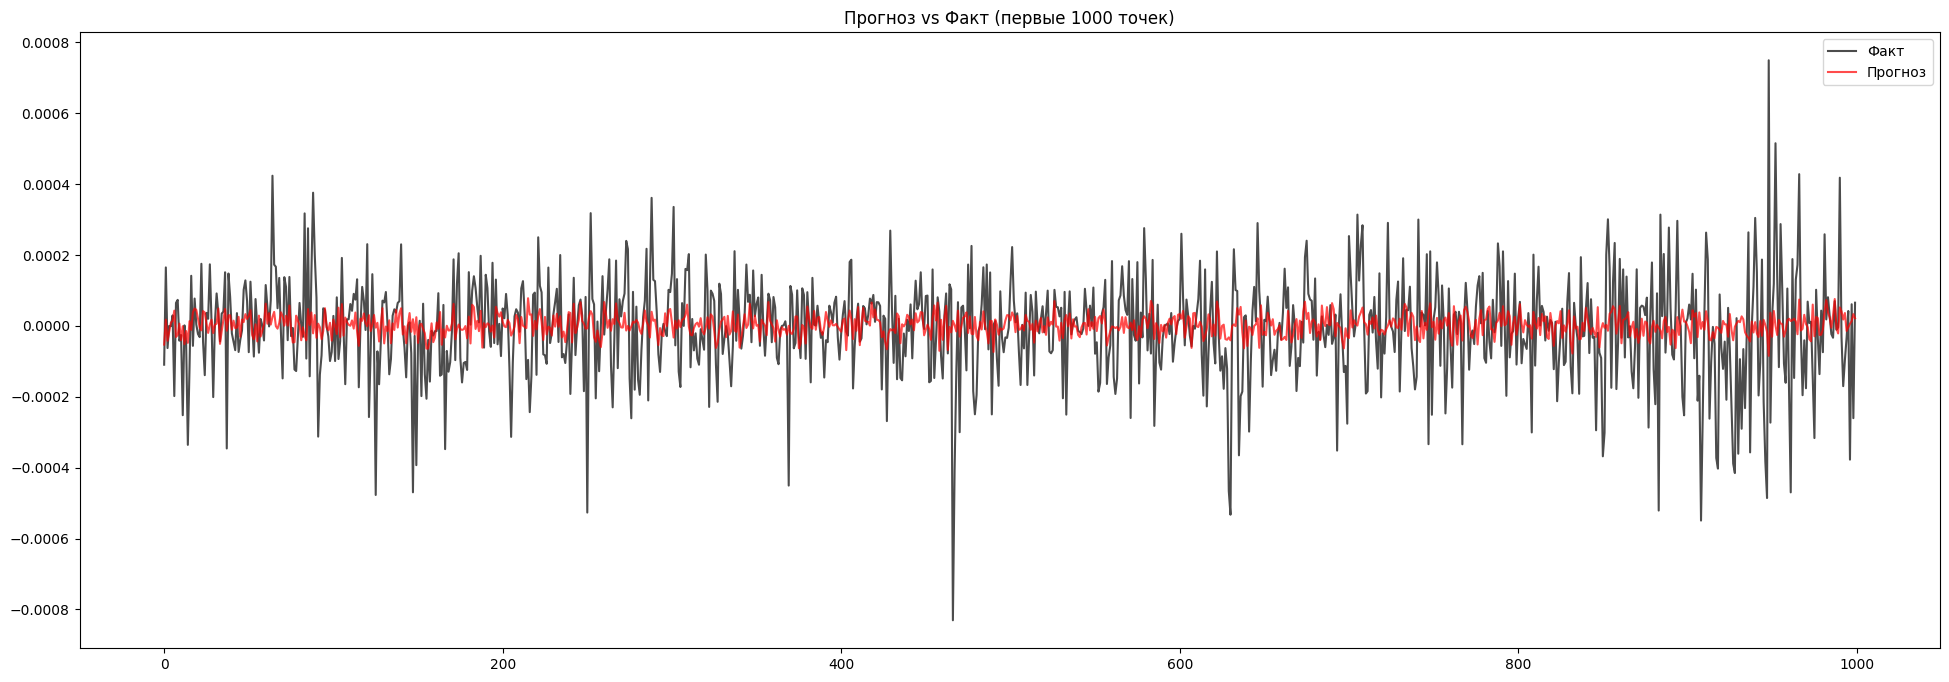

In [8]:
from src.mlcore.evaluation import evaluate_regression_model

y_mid_pred = mid_model.predict(X_test)

evaluate_regression_model(
    y_test=y_mid_test,
    y_pred=y_mid_pred,
    length=1000,
)

### Обучаем spread model

In [9]:
from src.mlcore.train import train_regression_model

spread_model = train_regression_model(
    X_train=X_train,
    y_train=y_spread_train,
    X_test=X_test,
    y_test=y_spread_test,
    n_estimators=5000,
    objective='reg:squaredlogerror',
    model_name="model_spread",
    max_depth=6,
)

Обучение модели...
[0]	validation_0-rmse:0.00025
[50]	validation_0-rmse:0.00021
[100]	validation_0-rmse:0.00020
[150]	validation_0-rmse:0.00019
[200]	validation_0-rmse:0.00019
[250]	validation_0-rmse:0.00019
[300]	validation_0-rmse:0.00019
[350]	validation_0-rmse:0.00019
[400]	validation_0-rmse:0.00019
[450]	validation_0-rmse:0.00019
[465]	validation_0-rmse:0.00019
Модель сохранена в директорию: models/model_spread.json


MAE                      : 0.000126
RMSE                     : 0.000185
R²                       : 0.445658
MAE / mean|Δ|            : 0.512102
RMSE / RMSE_base         : 0.529220
mean|Δ| (target)         : 0.000246

------------------------------------------------------------
Directional Accuracy     : 0.945795
Target Pos Ratio         : 0.945795
Profit Factor            : 17935749739.359493
Avg Gain (correct)       : 0.000260
Avg Loss (incorrect)     : 0.000000

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.9442, 0.9475)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
            quantile  confidence  directional_acc  mean_return  n_samples
 (0.000475, 0.00232]    0.000651         1.000000     0.000647       7280
(0.000338, 0.000475]    0.000400         0.999313     0.000393       7280
 (0.00027, 0.000338]    0.000300         0.995879     0.000289    

/Users/honeysuckle/dev/AlgoTradingSystem_v13.0/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


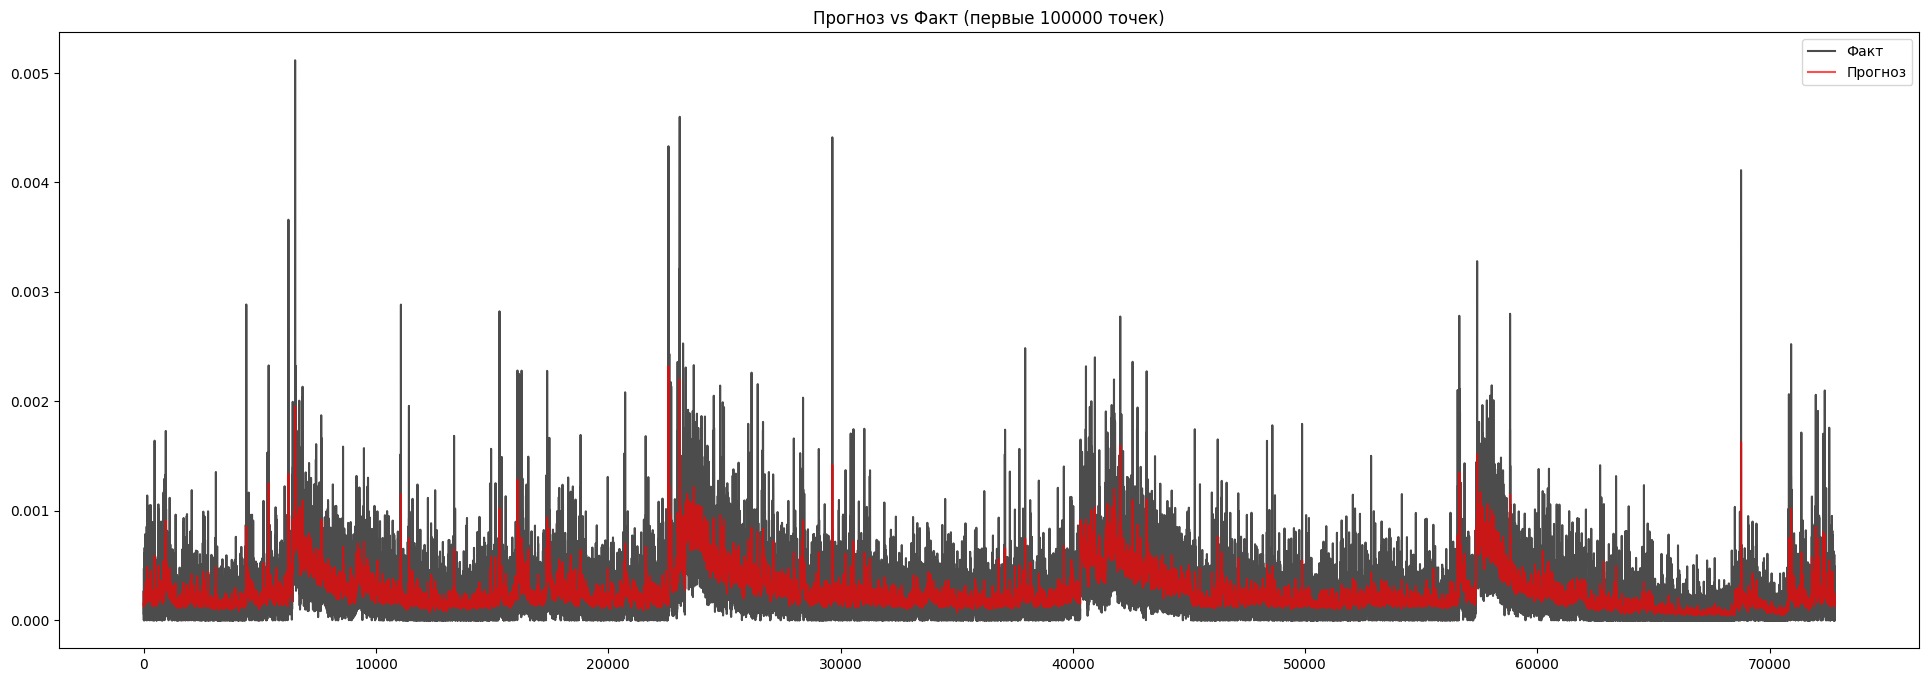

In [10]:
from src.mlcore.evaluation import evaluate_regression_model

y_spread_pred = spread_model.predict(X_test)

evaluate_regression_model(
    y_test=y_spread_test,
    y_pred=y_spread_pred,
    length=100000,
)